### Data investigation

In [1]:
import pandas as pd
from pathlib import Path

sessions_train_path = Path("data/sessions_train.csv")
products_train_path = Path("data/products_train.csv")

sessions_df = pd.read_csv(sessions_train_path)
products_df = pd.read_csv(products_train_path)

print("Sessions:")
print(sessions_df.head())
print("\n\nProducts:")
print(products_df.head())

Sessions:
                                          prev_items   next_item locale
0                        ['B09W9FND7K' 'B09JSPLN1M']  B09M7GY217     DE
1  ['B076THCGSG' 'B007MO8IME' 'B08MF65MLV' 'B001B...  B001B4THSA     DE
2  ['B0B1LGXWDS' 'B00AZYORS2' 'B0B1LGXWDS' 'B00AZ...  B0767DTG2Q     DE
3  ['B09XMTWDVT' 'B0B4MZZ8MB' 'B0B7HZ2GWX' 'B09XM...  B0B4R9NN4B     DE
4           ['B09Y5CSL3T' 'B09Y5DPTXN' 'B09FKD61R8']  B0BGVBKWGZ     DE


Products:
           id locale                                              title  \
0  B005ZSSN10     DE  RED DRAGON Amberjack 3 - Steel Tip 22 Gramm Wo...   
1  B08PRYN6LD     DE  Simply Keto Lower Carb* Schokodrops ohne Zucke...   
2  B09MBZJ48V     DE  Sennheiser 508377 PC 5.2 Chat, Stilvolles Mult...   
3  B08ZN6F26S     DE  AmyBenton Auto ab 1 2 3 ahre - Baby Aufziehbar...   
4  B094DGRV7D     DE      PLAYMOBIL - 70522 - Cavaliere mit grauem Pony   

   price         brand              color              size    model  \
0  30.95    RED DRAGON 

### Frequency information on session locations

In [2]:
sessions_df['locale'].value_counts()

locale
UK    1182181
DE    1111416
JP     979119
IT     126925
FR     117561
ES      89047
Name: count, dtype: int64

### Session length distribution

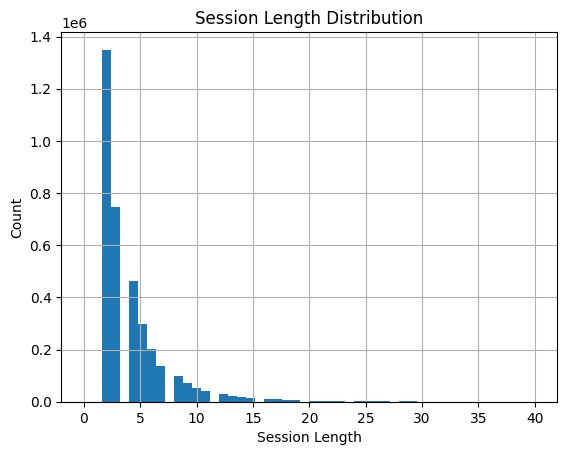

count    3.606249e+06
mean     4.244350e+00
std      3.548881e+00
min      2.000000e+00
25%      2.000000e+00
50%      3.000000e+00
75%      5.000000e+00
max      4.740000e+02
Name: prev_items, dtype: float64

In [3]:
import re
import matplotlib.pyplot as plt

prev_items = sessions_df['prev_items']

def count_items(items_str: str) -> int:
    return len(re.findall(r"[A-Z0-9]{10}", items_str))

item_counts = prev_items.apply(count_items)
item_counts.hist(bins=50, range=(0,40))
plt.xlabel("Session Length")
plt.ylabel("Count")
plt.title("Session Length Distribution")
plt.show()
item_counts.describe()